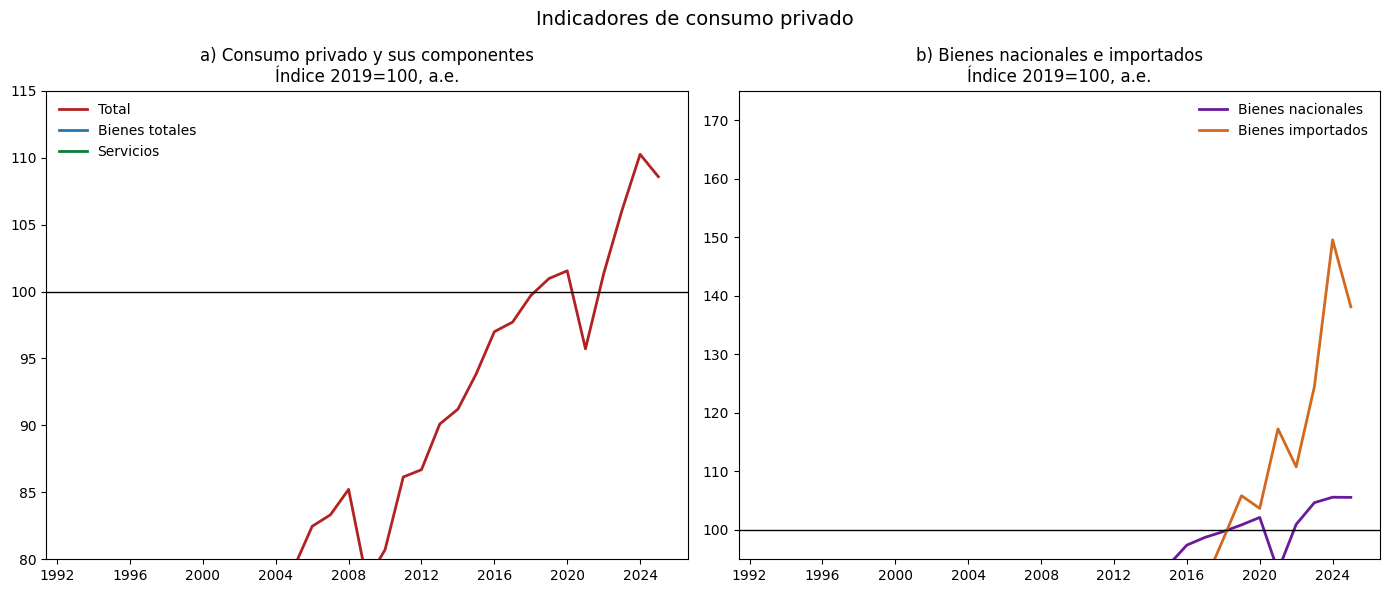

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# CONFIG
# =====================================
PATH = "raw/cp_indice.xlsx"
SHEET = "CP-indice"


MONTH_MAP = {
    "ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,
    "JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12
}

# =====================================
# 1) LEER TODO SIN HEADER
# =====================================
raw = pd.read_excel(PATH, sheet_name=SHEET, header=None)

# -------------------------------------
# localizar fila donde están los meses
# -------------------------------------
month_row = None
for i in range(20):
    row = raw.iloc[i].astype(str).str.upper()
    if row.isin(MONTH_MAP.keys()).sum() >= 6:
        month_row = i
        break

assert month_row is not None, "No encontré fila de meses"

# la fila de arriba trae los años
year_row = month_row - 1

months = raw.iloc[month_row]
years  = raw.iloc[year_row]

# =====================================
# 2) ARMAR COLUMNAS FECHA
# =====================================
dates = []

for m, y in zip(months, years):

    m = str(m).strip().upper()[:3]

    if m not in MONTH_MAP:
        dates.append(None)
        continue

    try:
        y = int(float(y))
    except:
        dates.append(None)
        continue

    dates.append(pd.Timestamp(y, MONTH_MAP[m], 1))

# =====================================
# 3) EXTRAER MATRIZ NUMÉRICA
# =====================================
data = raw.iloc[month_row+1:].copy()

data = data.rename(columns={0: "serie"})
data = data.dropna(subset=["serie"])

# quedarnos solo con columnas válidas
valid_cols = [i for i,d in enumerate(dates) if d is not None]
data = data.iloc[:, [0] + valid_cols]

dates = [dates[i] for i in valid_cols]
data.columns = ["serie"] + dates

# quitar notas
data = data[~data["serie"].astype(str).str.contains("NOTA|FUENTE", case=False)]

# =====================================
# 4) PASAR A LARGO
# =====================================
long = data.melt(id_vars="serie", var_name="date", value_name="value")
long["date"] = pd.to_datetime(long["date"])
long = long.dropna(subset=["value"])

# =====================================
# 5) SACAR SERIES
# =====================================
def get(name):
    return (
        long[long["serie"].str.contains(name, case=False)]
        .set_index("date")
        .sort_index()["value"]
    )

total     = get("^TOTAL$")
bienes    = get("^Bienes$")
servicios = get("Servicios")
nacional  = get("^Nacional$")
importado = get("Importado")

# =====================================
# 6) GRAFICAR
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True)

RED="#b22222"; BLUE="#1f77b4"; GREEN="#0b7d3e"
PURPLE="#6a1b9a"; ORANGE="#d2691e"

# ---- panel a
ax = axes[0]
ax.plot(total, color=RED, lw=2, label="Total")
ax.plot(bienes, color=BLUE, lw=2, label="Bienes totales")
ax.plot(servicios, color=GREEN, lw=2, label="Servicios")
ax.axhline(100, color="black", lw=1)

ax.set_title("a) Consumo privado y sus componentes\nÍndice 2019=100, a.e.")
ax.legend(frameon=False)
ax.set_ylim(80,115)

# ---- panel b
ax = axes[1]
ax.plot(nacional, color=PURPLE, lw=2, label="Bienes nacionales")
ax.plot(importado, color=ORANGE, lw=2, label="Bienes importados")
ax.axhline(100, color="black", lw=1)

ax.set_title("b) Bienes nacionales e importados\nÍndice 2019=100, a.e.")
ax.legend(frameon=False)
ax.set_ylim(95,175)

fig.suptitle("Indicadores de consumo privado", fontsize=14)
plt.tight_layout()
plt.show()


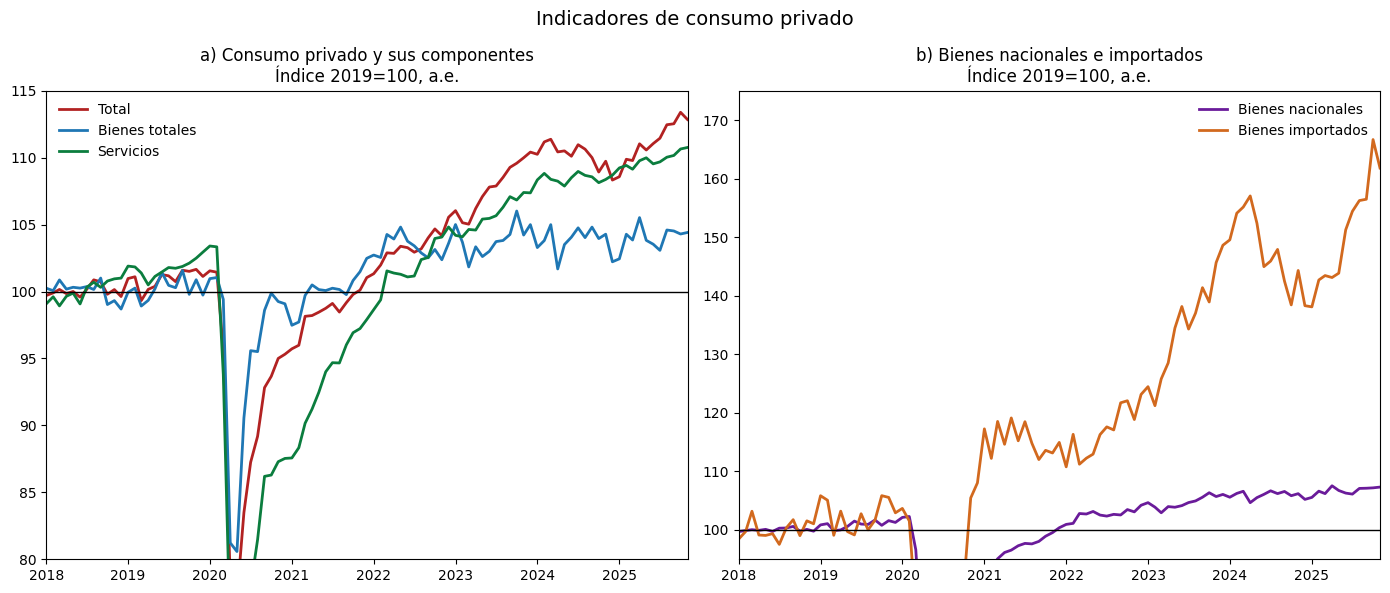

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# =====================================
# CONFIG
# =====================================
PATH  = "raw/cp_indice.xlsx"
SHEET = "CP-indice"
START = "2018-01-01"

MONTH_MAP = {
    "ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,
    "JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12
}

# Colores
RED    = "#b22222"
BLUE   = "#1f77b4"
GREEN  = "#0b7d3e"
PURPLE = "#6a1b9a"
ORANGE = "#d2691e"

# =====================================
# 1) LEER HOJA COMPLETA (sin header)
# =====================================
raw = pd.read_excel(PATH, sheet_name=SHEET, header=None)

# =====================================
# 2) IDENTIFICAR FILA DE MESES (ENE...DIC)
# =====================================
month_row = None
for i in range(80):
    row = raw.iloc[i].astype(str).str.upper().str.strip()
    if row.isin(MONTH_MAP.keys()).sum() >= 6:
        month_row = i
        break
if month_row is None:
    raise ValueError("No encontré la fila de meses (ENE..DIC).")

year_row = month_row - 1

months = raw.iloc[month_row]
years  = raw.iloc[year_row]

# =====================================
# 3) CONSTRUIR FECHAS POR COLUMNA
#    (año aparece en ENE y luego NaN -> fill forward)
# =====================================
dates = []
current_year = None

for m, y in zip(months, years):
    m3 = str(m).strip().upper()[:3]
    if m3 not in MONTH_MAP:
        dates.append(None)
        continue

    # actualizar año si viene
    try:
        if pd.notna(y):
            current_year = int(float(y))
    except:
        pass

    if current_year is None:
        dates.append(None)
        continue

    dates.append(pd.Timestamp(current_year, MONTH_MAP[m3], 1))

valid_idx = [j for j, d in enumerate(dates) if d is not None]
valid_dates = [dates[j] for j in valid_idx]

# =====================================
# 4) ARMAR MATRIZ (series x fechas)
#    Serie = col A si existe; si no, col B
# =====================================
data = raw.iloc[month_row + 1:, :].copy()

def norm(s):
    s = "" if pd.isna(s) else str(s)
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

serie_A = data.iloc[:, 0].map(norm)
serie_B = data.iloc[:, 1].map(norm)
data["serie"] = np.where(serie_A != "", serie_A, serie_B)
data = data[data["serie"] != ""]

# quitar notas/fuente
data = data[~pd.Series(data["serie"]).str.contains("NOTA|FUENTE", case=False, na=False)]

# quedarnos con columnas de meses válidas
mat = data.iloc[:, valid_idx].copy()
mat.columns = valid_dates
mat.insert(0, "serie", data["serie"].values)

# =====================================
# 5) PASAR A LARGO
# =====================================
long = mat.melt(id_vars="serie", var_name="date", value_name="value")
long["date"] = pd.to_datetime(long["date"])
long["value"] = pd.to_numeric(long["value"], errors="coerce")
long = long.dropna(subset=["value"])

# =====================================
# 6) EXTRAER SERIES (exactas, ya normalizadas)
# =====================================
def pick(name_exact):
    s = long[long["serie"].str.lower() == name_exact.lower()].set_index("date").sort_index()["value"]
    return s

total     = pick("TOTAL")
nacional  = pick("Nacional")
bienes    = pick("Bienes")
servicios = pick("Servicios")
importado = pick("Importado")  # en tu archivo puede traer espacios; norm() ya los quitó

# =====================================
# 7) RECORTAR DESDE 2018
# =====================================
total     = total.loc[START:]
nacional  = nacional.loc[START:]
bienes    = bienes.loc[START:]
servicios = servicios.loc[START:]
importado = importado.loc[START:]

# =====================================
# 8) GRAFICAR (2 paneles, ejes desde 2018)
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Panel a
ax = axes[0]
ax.plot(total.index, total.values, color=RED, lw=2, label="Total")
ax.plot(bienes.index, bienes.values, color=BLUE, lw=2, label="Bienes totales")
ax.plot(servicios.index, servicios.values, color=GREEN, lw=2, label="Servicios")
ax.axhline(100, color="black", lw=1)

ax.set_title("a) Consumo privado y sus componentes\nÍndice 2019=100, a.e.")
ax.legend(frameon=False, loc="upper left")
ax.set_ylim(80, 115)
ax.set_xlim(pd.Timestamp(START), total.index.max())

# Panel b
ax = axes[1]
ax.plot(nacional.index, nacional.values, color=PURPLE, lw=2, label="Bienes nacionales")
ax.plot(importado.index, importado.values, color=ORANGE, lw=2, label="Bienes importados")
ax.axhline(100, color="black", lw=1)

ax.set_title("b) Bienes nacionales e importados\nÍndice 2019=100, a.e.")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(95, 175)
ax.set_xlim(pd.Timestamp(START), importado.index.max())

fig.suptitle("Indicadores de consumo privado", fontsize=14)
plt.tight_layout()
plt.show()
